## Smoothing

### Imports

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import util


### Load Image and add noise

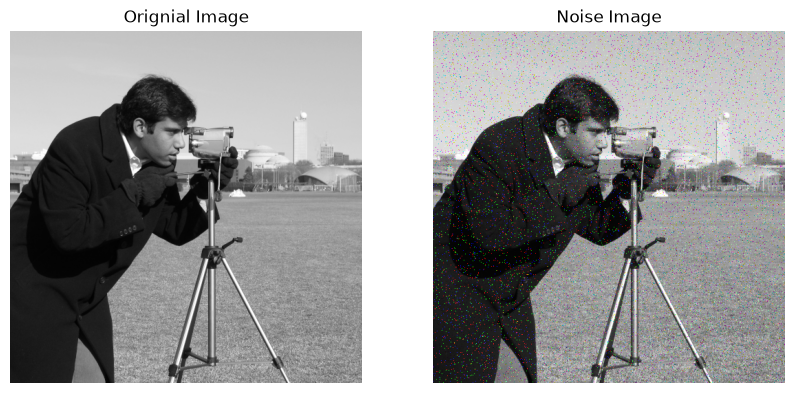

In [7]:
# Image
img = cv.imread("output/camera.png")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Add Noise
noisy = util.random_noise(img, mode="s&p", amount=0.03)
noisy = (noisy * 255).astype(np.uint8)

# Show
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis("off")
plt.title("Orignial Image")

plt.subplot(1,2,2)
plt.imshow(noisy)
plt.axis("off")
plt.title("Noise Image")

plt.show()

In [8]:
kernels = [3, 7, 15]
results = []
titles = []

In [9]:
# Gaussian Blur
for k in kernels:
    titles.append(f"Gaussian {k}")
    results.append(cv.GaussianBlur(noisy, (k, k), 0))

# Bilateral Filter
for k in kernels:
    titles.append(f"Bilateral {k}")
    results.append(cv.bilateralFilter(noisy, k, 75, 75))

# Median Blur
for k in kernels:
    titles.append(f"Median {k}")
    results.append(cv.medianBlur(noisy, k))

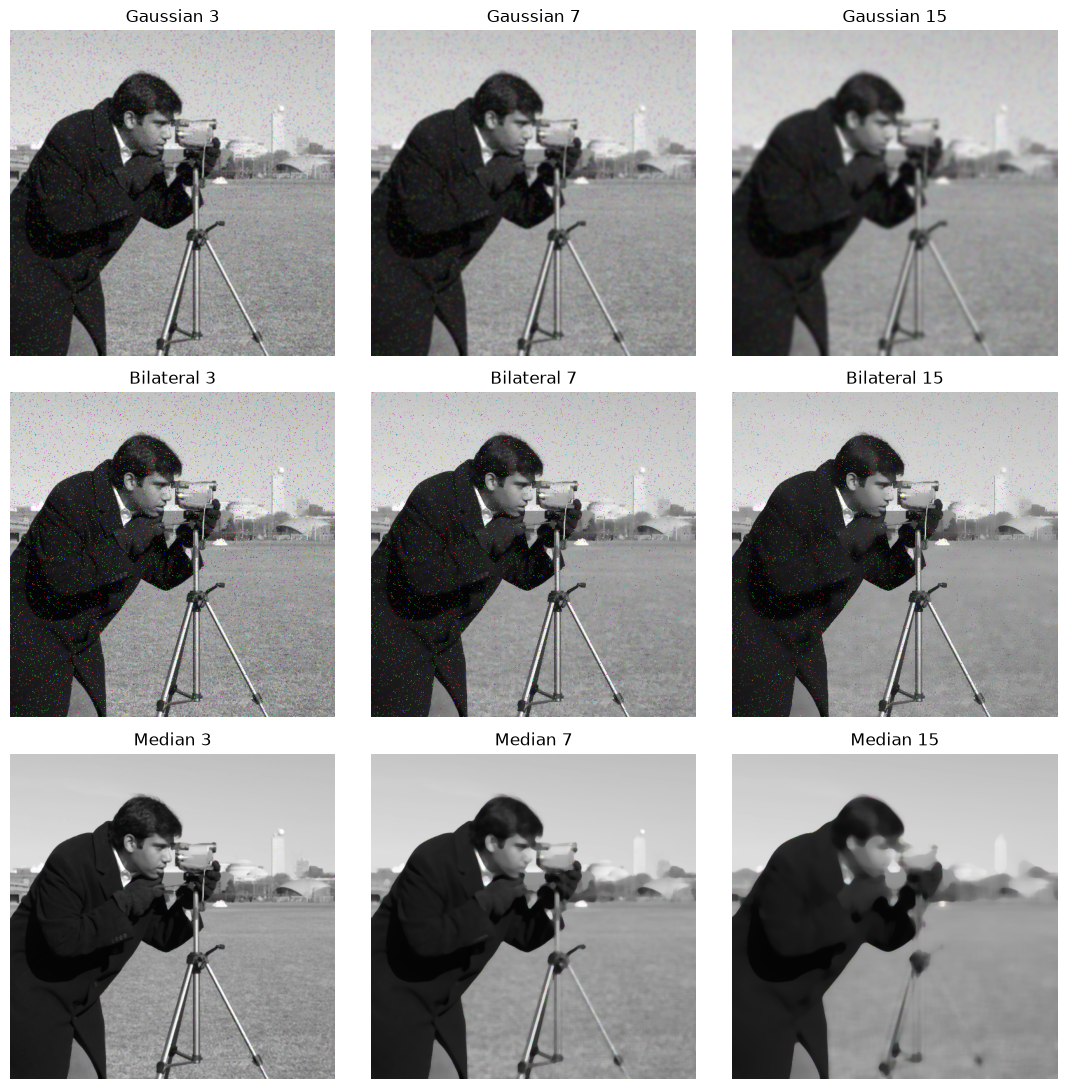

In [10]:
plt.figure(figsize=(11, 11))
i=0

for result, title in zip(results, titles):
    plt.subplot(3, 3, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")
    i+=1

plt.tight_layout()
plt.savefig("output/2_smoothing.png", dpi=300)
plt.show()